<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=200>

*Milton Orlando Sarria Paja, PhD.*

----

### **Práctica: Predicción del Valor de Mercado de Jugadores de Fútbol**

**Objetivo General:** Utilizar técnicas de regresión lineal para construir modelos que predigan el valor de mercado de un jugador (`Value_millions`) basándose en sus atributos de rendimiento y características personales.

---

### **Ejercicio 1: Identificación de Variables y Análisis de Dependencia 🔍**

El primer paso en cualquier proyecto de modelado es entender profundamente los datos con los que trabajamos.

**Tareas:**

1.  **Identificar Variables Relevantes:**
    * Del listado de columnas, crea una lista de **todas las variables numéricas** que podrían ser útiles para predecir el valor de un jugador.
    * Excluye explícitamente las variables que son identificadores (como `player_id`) o categóricas puras (como `player_name`, `country`, `position`, `club_name`, etc.).

2.  **Análisis de Correlación:**
    * Una vez cargados los datos, calcula la matriz de correlación entre todas las variables numéricas que identificaste y la variable objetivo `Value_millions`.
    * Visualiza esta matriz utilizando un **mapa de calor (heatmap)**. Esto te dará una visión rápida de las relaciones lineales más fuertes.

3.  **Análisis Visual:**
    * Crea **gráficos de dispersión (scatter plots)** para visualizar la relación entre `Value_millions` y las 3-4 variables que mostraron la correlación más alta en el paso anterior.

**Preguntas para Reflexión y Discusión:**

* **Pregunta 1.1:** Según el mapa de calor, ¿cuáles son las tres variables con la correlación positiva más fuerte con `Value_millions`?
* **Pregunta 1.2:** Observa el gráfico de dispersión de `age` vs. `Value_millions`. ¿La relación parece ser una línea recta? Describe la forma que observas. (Esta observación será clave para el Ejercicio 5).
* **Pregunta 1.3:** ¿Qué variable, si alguna, parece tener una relación lineal casi perfecta con `Value_millions`? ¿Podría esto ser un problema o es algo esperado?

---

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('2-base_taller_csv.csv', delimiter=';')
print(df)

       player_id                     player_name  age              country  \
0         231747            Kylian Mbappé Lottin   23               France   
1         192985                 Kevin De Bruyne   31              Belgium   
2         188545              Robert Lewandowski   33               Poland   
3         165153                   Karim Benzema   34               France   
4         158023  Lionel Andrés Messi Cuccittini   35            Argentina   
...          ...                             ...  ...                  ...   
22075     261876                    Conan Noonan   19  Republic of Ireland   
22076     254232              Mohammed Asif Khan   21                India   
22077     259213                 Antonio D'Silva   22                India   
22078     258802                 Bhupender Singh   22                India   
22079     271608               Aqeel Al Dhafeeri   17         Saudi Arabia   

       height_cm  weight_lbs position  overall  potential Value

In [3]:
variable_int = {col: df[col].dtype for col in df.columns } # if str(df[col].dtype).startswith('int')

print(variable_int)

{'player_id': dtype('int64'), 'player_name': dtype('O'), 'age': dtype('int64'), 'country': dtype('O'), 'height_cm': dtype('int64'), 'weight_lbs': dtype('int64'), 'position': dtype('O'), 'overall': dtype('int64'), 'potential': dtype('int64'), 'Value_millions': dtype('O'), 'pref_foot': dtype('O'), 'weak_foot': dtype('int64'), 'skill_moves': dtype('int64'), 'international_reputation': dtype('int64'), 'Attacking_work_rate': dtype('O'), 'Defensive_work_rate': dtype('O'), 'body_type': dtype('O'), 'club_country': dtype('O'), 'club_name': dtype('O'), 'club_overall': dtype('int64')}


In [4]:
not_important = ['player_id']
select_variable_int = {key: value for key, value in variable_int.items() if key not in not_important}

print(select_variable_int)

{'player_name': dtype('O'), 'age': dtype('int64'), 'country': dtype('O'), 'height_cm': dtype('int64'), 'weight_lbs': dtype('int64'), 'position': dtype('O'), 'overall': dtype('int64'), 'potential': dtype('int64'), 'Value_millions': dtype('O'), 'pref_foot': dtype('O'), 'weak_foot': dtype('int64'), 'skill_moves': dtype('int64'), 'international_reputation': dtype('int64'), 'Attacking_work_rate': dtype('O'), 'Defensive_work_rate': dtype('O'), 'body_type': dtype('O'), 'club_country': dtype('O'), 'club_name': dtype('O'), 'club_overall': dtype('int64')}


In [5]:
correlation_Df = df.corr(numeric_only=True)
print(correlation_Df)

                          player_id       age  height_cm  weight_lbs  \
player_id                  1.000000 -0.779513  -0.076063   -0.187598   
age                       -0.779513  1.000000   0.063914    0.225019   
height_cm                 -0.076063  0.063914   1.000000    0.754044   
weight_lbs                -0.187598  0.225019   0.754044    1.000000   
overall                   -0.469931  0.461621   0.036135    0.142046   
potential                  0.082688 -0.256956   0.024385   -0.002775   
weak_foot                 -0.114190  0.072891  -0.152746   -0.123012   
skill_moves               -0.124383  0.072518  -0.436694   -0.359683   
international_reputation  -0.311095  0.239381   0.040735    0.087162   
club_overall              -0.106433  0.022354   0.061363    0.069662   

                           overall  potential  weak_foot  skill_moves  \
player_id                -0.469931   0.082688  -0.114190    -0.124383   
age                       0.461621  -0.256956   0.072891     

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
cols_utiles = [
    'Value_millions', 'age', 'height_cm', 'weight_lbs',
    'overall', 'potential', 'weak_foot',
    'skill_moves', 'international_reputation', 'club_overall'
]
df = df[cols_utiles]

print(df)


      Value_millions  age  height_cm  weight_lbs  overall  potential  \
0              190,5   23        182         161       91         95   
1              107,5   31        181         165       91         91   
2                 84   33        185         179       91         91   
3                 64   34        185         179       91         91   
4                 54   35        169         148       91         91   
...              ...  ...        ...         ...      ...        ...   
22075           0,17   19        180         148       52         63   
22076           0,12   21        171         121       46         58   
22077           0,11   22        182         161       51         61   
22078           0,11   22        172         157       46         54   
22079           0,11   17        180         154       46         63   

       weak_foot  skill_moves  international_reputation  club_overall  
0              4            5                         4        

In [8]:
print(77)
print(df['Value_millions'].unique()[:1000])

77
['190,5' '107,5' '84' '64' '54' '160' '90' '79' '105,5' '99,5' '86' '11,5'
 '103,5' '97,5' '78' '92' '84,5' '89,5' '68,5' '72' '29' '88,5' '116,5'
 '80' '72,5' '101' '77,5' '42' '27' '102' '109' '61' '94' '61,5' '64,5'
 '69,5' '73,5' '55,5' '45,5' '9' '55' '36' '33,5' '81,5' '104,5' '65,5'
 '57,5' '71' '76' '67,5' '68' '46,5' '63,5' '59' '46' '28,5' '59,5' '53'
 '44,5' '37' '45' '26' '43' '26,5' '28' '44' '22' '12' '78,5' '66' '52'
 '86,5' '66,5' '62,5' '50,5' '57' '53,5' '60,5' '56' '47,5' '43,5' '54,5'
 '58' '47' '41,5' '42,5' '40,5' '36,5' '35,5' '52,5' '31,5' '35' '30,5'
 '20,5' '17,5' '6' '7,5' '48' '49,5' '38,5' '38' '40' '39,5' '27,5' '39'
 '21' '34,5' '24' '23,5' '12,5' '14,5' '20' '13' '17' '37,5' '49' '34'
 '25' '29,5' '25,5' '32' '31' '30' '32,5' '33' '10' '16' '19' '8,5' '8'
 '19,5' '14' '3,4' '4' '5,5' '24,5' '22,5' '21,5' '18,5' '15' '9,5' '23'
 '18' '11' '4,4' '4,6' '7' '16,5' '15,5' '13,5' '2,3' '2,9' '3,6' '3,8'
 '0' '3' '10,5' '2,4' '1,9' '6,5' '5' '2,8' '2,5' '3,3

In [9]:
df['Value_millions'] = df['Value_millions'].str.replace(',', '.', regex=False).astype(float)


In [10]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
print(77)
print(numeric_df)

77
       Value_millions  age  height_cm  weight_lbs  overall  potential  \
0              190.50   23        182         161       91         95   
1              107.50   31        181         165       91         91   
2               84.00   33        185         179       91         91   
3               64.00   34        185         179       91         91   
4               54.00   35        169         148       91         91   
...               ...  ...        ...         ...      ...        ...   
22075            0.17   19        180         148       52         63   
22076            0.12   21        171         121       46         58   
22077            0.11   22        182         161       51         61   
22078            0.11   22        172         157       46         54   
22079            0.11   17        180         154       46         63   

       weak_foot  skill_moves  international_reputation  club_overall  
0              4            5                   

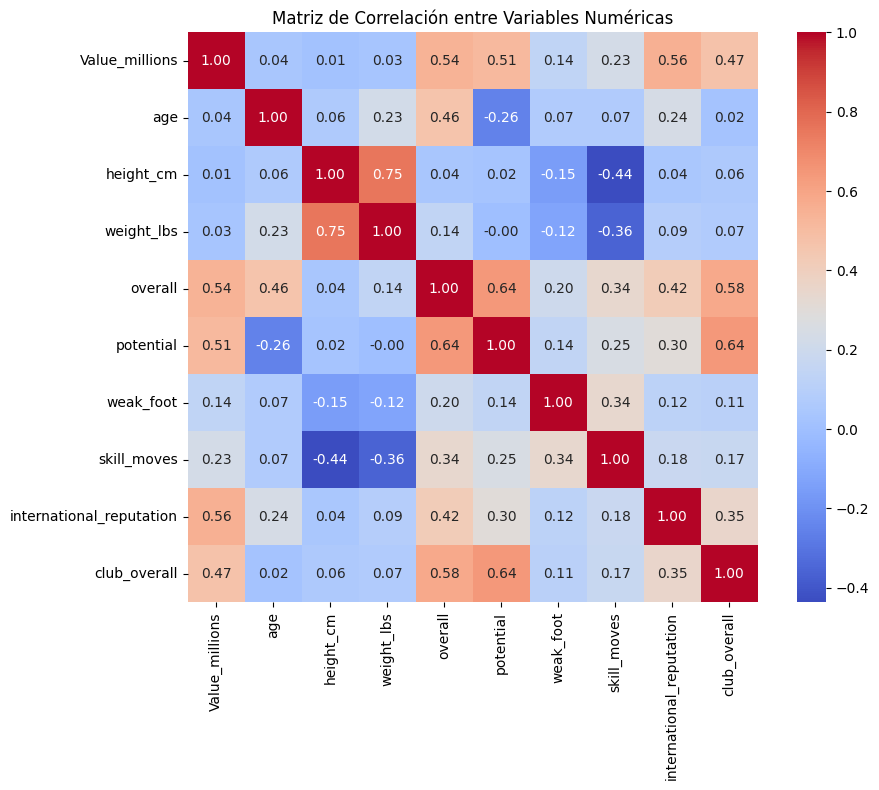

📊 Correlación con 'Value_millions':
Value_millions              1.000000
international_reputation    0.555256
overall                     0.543204
potential                   0.512392
club_overall                0.467281
skill_moves                 0.230581
weak_foot                   0.140975
age                         0.038467
weight_lbs                  0.029716
height_cm                   0.014909
Name: Value_millions, dtype: float64


In [11]:
if 'Value_millions' not in numeric_df.columns:
    print("⚠️ La columna 'Value_millions' no está en el DataFrame.")
else:
    # Paso 5: Calcular matriz de correlación
    corr_matrix = numeric_df.corr()

    # Paso 6: Crear un mapa de calor
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar=True)
    plt.title("Matriz de Correlación entre Variables Numéricas")
    plt.tight_layout()
    plt.show()

    # Paso 7: Ver correlación específica con 'Value_millions'
    print("📊 Correlación con 'Value_millions':")
    print(corr_matrix["Value_millions"].sort_values(ascending=False))

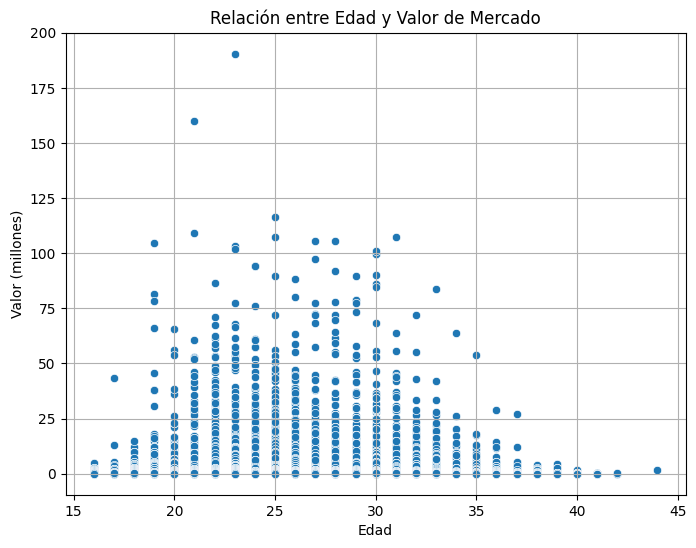

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='Value_millions')
plt.title('Relación entre Edad y Valor de Mercado')
plt.xlabel('Edad')
plt.ylabel('Valor (millones)')
plt.grid(True)
plt.show()

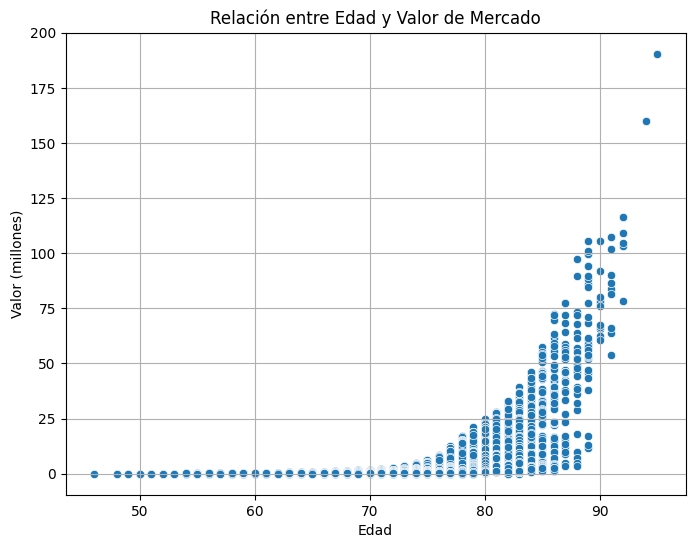

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='potential', y='Value_millions')
plt.title('Relación entre Edad y Valor de Mercado')
plt.xlabel('Edad')
plt.ylabel('Valor (millones)')
plt.grid(True)
plt.show()

### ¿Cuáles son las tres variables con la correlación positiva más fuerte con Value_millions?

* international_reputation    0.555256
* overall                     0.543204
* potential                   0.512392

### ¿La relación entre age y Value_millions parece ser una línea recta? Describe la forma que observas.

* Los jugadores muy jóvenes (18-24 años) tienden a tener valores altos si tienen alto potencial.
* Jugadores en sus mejores años (25-29) aún mantienen valores altos.
* Jugadores mayores (30+) muestran una caída en el valor.

### ¿Qué variable, si alguna, parece tener una relación lineal casi perfecta con Value_millions? ¿Podría esto ser un problema o es algo esperado?




### **Ejercicio 2: Regresión Lineal Simple y Verificación de Supuestos**

Ahora construiremos nuestro primer modelo predictivo utilizando solo la mejor variable predictora que encontramos.

**Tareas:**

1.  **Construir el Modelo:**
    * Selecciona la variable predictora que tuvo la correlación más alta con `Value_millions` en el ejercicio anterior (probablemente `overall` o `potential`).
    * Divide tus datos en un conjunto de entrenamiento (70%) y un conjunto de prueba (30%).
    * Entrena un modelo de Regresión Lineal Simple usando solo esta variable para predecir `Value_millions`.

2.  **Interpretar y Evaluar:**
    * Obtén e interpreta el intercepto ($\theta_0$) y el coeficiente ($\theta_1$) del modelo.
    * Calcula el coeficiente de determinación (R²) en el conjunto de prueba.

3.  **Verificar los Supuestos Teóricos:**
    * Calcula los **residuos** del modelo en el conjunto de prueba (valor real - valor predicho).
    * **Normalidad:** Crea un histograma de los residuos. ¿Siguen una distribución normal (forma de campana)?
    * **Homocedasticidad:** Crea un gráfico de dispersión con los valores predichos en el eje X y los residuos en el eje Y.

**Preguntas para Reflexión y Discusión:**

* **Pregunta 2.1:** Explica con tus propias palabras qué significa el coeficiente $\theta_1$ que obtuviste. Por ejemplo: "Por cada punto que aumenta [tu variable], el valor de mercado del jugador aumenta/disminuye en X millones de dólares".
* **Pregunta 2.2:** ¿Qué te dice el valor de R² sobre qué tan bien tu modelo de una sola variable puede explicar la variación en el valor de mercado de los jugadores?
* **Pregunta 2.3:** Observando el gráfico de residuos vs. valores predichos, ¿los puntos forman una nube aleatoria sin patrón alrededor de la línea cero, o ves alguna forma (como un cono o un embudo)? ¿Qué te dice esto sobre el supuesto de homocedasticidad?

---

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [21]:
X = df[['overall']]  # Variable predictora
y = df['Value_millions']  # Variable objetivo

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
theta_0 = modelo.intercept_
theta_1 = modelo.coef_[0]

print(f"Intercepto (θ₀): {theta_0:.2f}")
print(f"Coeficiente (θ₁): {theta_1:.2f}")

Intercepto (θ₀): -33.70
Coeficiente (θ₁): 0.56


In [23]:
from sklearn.metrics import r2_score

y_pred = modelo.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R² en conjunto de prueba: {r2:.3f}")


R² en conjunto de prueba: 0.285


In [24]:
residuos = y_test - y_pred
print(residuos)

19441   -0.392314
7861    -3.194696
2748    -3.252556
7462    -1.319696
4269    -3.797079
           ...   
15558    0.868639
9929    -1.558743
17007    2.890546
9816    -1.558743
2240    -5.752556
Name: Value_millions, Length: 6624, dtype: float64


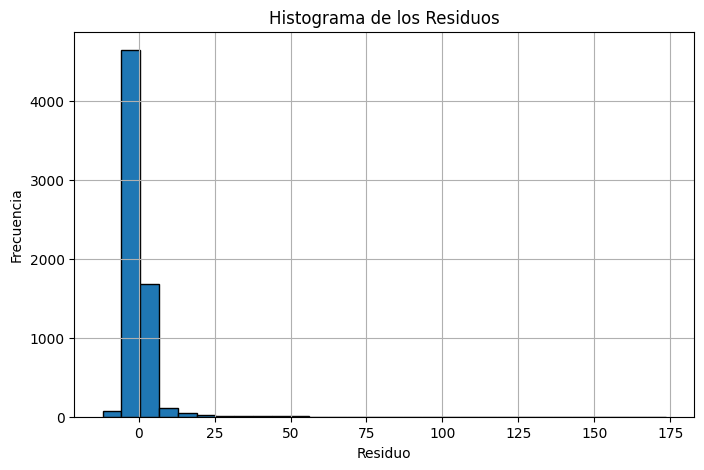

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(residuos, bins=30, edgecolor='black')
plt.title('Histograma de los Residuos')
plt.xlabel('Residuo')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


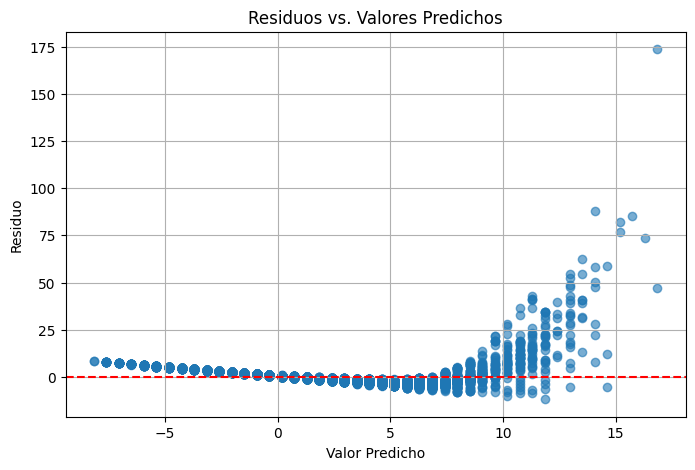

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuos, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs. Valores Predichos')
plt.xlabel('Valor Predicho')
plt.ylabel('Residuo')
plt.grid(True)
plt.show()


* **Pregunta 2.1:** Explica con tus propias palabras qué significa el coeficiente $\theta_1$ que obtuviste. Por ejemplo: "Por cada punto que aumenta [tu variable], el valor de mercado del jugador aumenta/disminuye en X millones de dólares".

El coeficiente $\theta_1$ = 0.56 significa que por cada punto adicional en el atributo overall, el valor de mercado del jugador aumenta en aproximadamente 0.56 millones, en promedio

* **Pregunta 2.2:** ¿Qué te dice el valor de R² sobre qué tan bien tu modelo de una sola variable puede explicar la variación en el valor de mercado de los jugadores?

El valor de R² = 0.285 indica que el modelo explica un 28.5% de la variación en Value_millions. Es una explicación parcial, lo cual es esperable porque solo estamos usando una variable. Más variables mejorarían el modelo

* **Pregunta 2.3:** Observando el gráfico de residuos vs. valores predichos, ¿los puntos forman una nube aleatoria sin patrón alrededor de la línea cero, o ves alguna forma (como un cono o un embudo)? ¿Qué te dice esto sobre el supuesto de homocedasticidad?

Existe un patrón, lo que indica que la homocedasticidad podría estar fallando. El modelo tiene errores que aumentan con el valor predicho


### **Ejercicio 3: Regresión Lineal Múltiple 🏙️**

Un solo atributo no es suficiente para determinar el valor de un jugador. Usemos múltiples variables para crear un modelo más robusto.

**Tareas:**

1.  **Construir el Modelo Múltiple:**
    * Selecciona un conjunto de 4 a 6 de las variables predictoras numéricas más prometedoras (ej. `overall`, `potential`, `age`, `international_reputation`, `skill_moves`, etc.).
    * Entrena un nuevo modelo de Regresión Lineal Múltiple utilizando todas estas variables para predecir `Value_millions`. Asegúrate de usar los mismos conjuntos de entrenamiento y prueba.

2.  **Interpretar y Evaluar:**
    * Obtén e imprime los coeficientes para cada una de las variables.
    * Calcula el nuevo R² del modelo múltiple.

**Preguntas para Reflexión y Discusión:**

* **Pregunta 3.1:** Compara el R² del modelo múltiple con el del modelo simple. ¿Mejoró significativamente el modelo al añadir más información?
* **Pregunta 3.2:** Observa el coeficiente de la variable `age`. ¿Es positivo o negativo? ¿Qué te dice esto sobre cómo cambia el valor de un jugador con la edad, *manteniendo constantes todos los demás factores como su `overall` y `potential`*?
* **Pregunta 3.3:** ¿Es posible que una variable que parecía importante en el análisis de correlación inicial tenga un coeficiente pequeño o inesperado en el modelo múltiple? ¿Por qué podría ocurrir esto?

---


In [28]:
from sklearn.model_selection import train_test_split

variables = ['overall', 'potential', 'age', 'international_reputation', 'skill_moves']
X = df[variables]
y = df['Value_millions']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [29]:
from sklearn.linear_model import LinearRegression

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
coeficientes = pd.Series(modelo_multiple.coef_, index=variables)
print("Coeficientes del modelo múltiple:")
print(coeficientes)

print(f"Intercepto: {modelo_multiple.intercept_:.2f}")


Coeficientes del modelo múltiple:
overall                     0.565123
potential                  -0.067893
age                        -0.472296
international_reputation    8.889221
skill_moves                -0.005379
dtype: float64
Intercepto: -27.34


In [31]:
from sklearn.metrics import r2_score

y_pred_multiple = modelo_multiple.predict(X_test)
r2_multiple = r2_score(y_test, y_pred_multiple)

print(f"R² del modelo múltiple: {r2_multiple:.3f}")


R² del modelo múltiple: 0.461


* **Pregunta 3.1:** Compara el R² del modelo múltiple con el del modelo simple. ¿Mejoró significativamente el modelo al añadir más información?

Sí, el modelo mejoró notablemente en la regresión lineal simple con una sola variable (overall), el R² fue aproximadamente 0.285 ahora con múltiples variables (overall, potential, age, international_reputation, skill_moves) el R² aumentó a 0.461.


* **Pregunta 3.2:** Observa el coeficiente de la variable `age`. ¿Es positivo o negativo? ¿Qué te dice esto sobre cómo cambia el valor de un jugador con la edad, *manteniendo constantes todos los demás factores como su `overall` y `potential`*?

El coeficiente de age fue -0.4723 esto significa que, manteniendo constantes las demás variables (overall, potential, age, international_reputation, skill_moves) por cada año adicional de edad, el valor de mercado de un jugador disminuye en aproximadamente 0.4723 millones.


* **Pregunta 3.3:** ¿Es posible que una variable que parecía importante en el análisis de correlación inicial tenga un coeficiente pequeño o inesperado en el modelo múltiple? ¿Por qué podría ocurrir esto?

Colinealidad: Si una variable está altamente correlacionada con otra (por ejemplo, overall y potential), el modelo no puede distinguir claramente cuál de las dos está aportando más a la predicción. Esto puede reducir el peso de una de ellas.

Efecto compartido: Una variable puede parecer importante cuando se analiza sola (alta correlación), pero su efecto real se reparte entre varias otras en el modelo múltiple.

Relaciones no lineales: Puede que la relación entre una variable y el valor de mercado no sea lineal, y el modelo lineal no lo capture bien.

Interacción con otras variables: La importancia de una variable puede depender del valor de otras (por ejemplo, la edad afecta distinto a jugadores con alto potencial que a los de bajo potencial).

Conclusión: Es completamente normal que una variable con alta correlación inicial tenga un coeficiente bajo o incluso negativo en un modelo múltiple. Por eso es importante usar regresión múltiple y no solo mirar correlaciones simples.


### **Ejercicio 4: Regresión Lineal Polinomial 🎢**

Recordemos la relación entre `age` y `Value_millions`. No era lineal. Vamos a intentar capturar esa curva.

**Tareas:**

1.  **Construir el Modelo Polinomial:**
    * Enfócate nuevamente en predecir `Value_millions` usando únicamente la variable `age`.
    * Crea un modelo de Regresión Polinomial de **grado 2**. Esto significa que usarás `age` y `age²` como tus características. (Sugerencia: usa `PolynomialFeatures` de Scikit-Learn dentro de un `Pipeline`).
    * Entrena el modelo.

2.  **Visualizar y Evaluar:**
    * Crea un gráfico de dispersión de `age` vs. `Value_millions`.
    * Superpón en el mismo gráfico la curva de tu modelo polinomial ajustado.
    * Compara el R² de este modelo con el R² del modelo de regresión simple que usaba solo `age`.

**Preguntas para Reflexión y Discusión:**

* **Pregunta 4.1:** Viendo el gráfico, ¿el modelo polinomial de grado 2 captura mejor la relación entre la edad y el valor de mercado que una simple línea recta?
* **Pregunta 4.2 (Reto):** Intenta construir un modelo polinomial de grado muy alto (ej. grado 10) usando `age`. ¿Qué le pasa a la curva? Explica con tus palabras por qué este modelo, aunque se ajuste muy bien a los datos de entrenamiento, es un mal modelo. ¿Cómo se llama este fenómeno?

In [33]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


In [41]:
modelo_polinomial = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('regresion', LinearRegression())
])
# Variable predictora y objetivo
X_poly = df[['age']]
y_poly = df['Value_millions']

# Entrenamiento del modelo
modelo_polinomial.fit(X_poly, y_poly)

,steps,"[('poly_features', ...), ('regresion', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


c:\Users\Pipicano\Music\Semester I\Aprendizaje automatico I\Exercise\enExercise\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


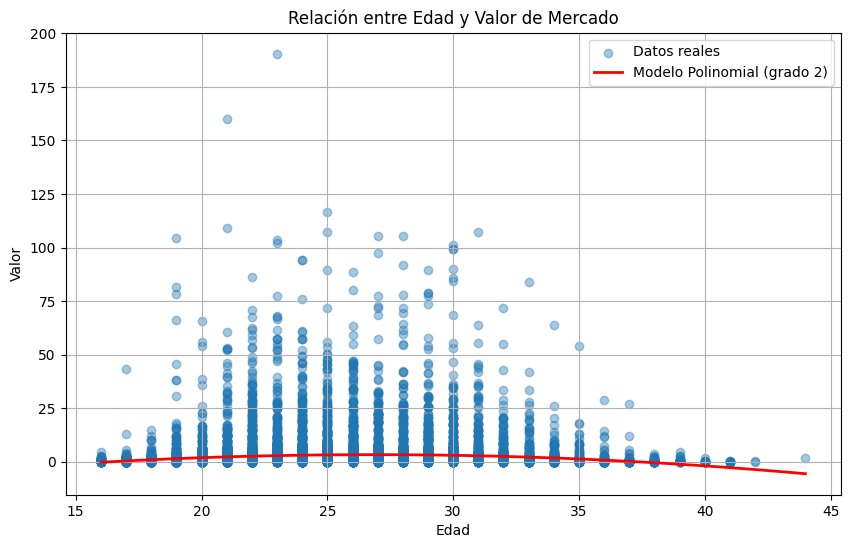

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Rango de edades para graficar la curva suavizada
age_range = np.linspace(df['age'].min(), df['age'].max(), 300).reshape(-1, 1)
value_pred = modelo_polinomial.predict(age_range)

# Gráfico
plt.figure(figsize=(10,6))
plt.scatter(df['age'], df['Value_millions'], alpha=0.4, label='Datos reales')
plt.plot(age_range, value_pred, color='red', linewidth=2, label='Modelo Polinomial (grado 2)')
plt.title('Relación entre Edad y Valor de Mercado')
plt.xlabel('Edad')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()


In [44]:
from sklearn.metrics import r2_score

# R² del modelo polinomial
r2_poly = r2_score(y_poly, modelo_polinomial.predict(X_poly))

# R² del modelo lineal simple
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_poly, y_poly)
r2_lineal = r2_score(y_poly, modelo_lineal.predict(X_poly))

print(f"R² del modelo lineal simple con age: {r2_lineal:.3f}")
print(f"R² del modelo polinomial (grado 2): {r2_poly:.3f}")


R² del modelo lineal simple con age: 0.001
R² del modelo polinomial (grado 2): 0.016


* **Pregunta 4.1:** Viendo el gráfico, ¿el modelo polinomial de grado 2 captura mejor la relación entre la edad y el valor de mercado que una simple línea recta?

Sí. El modelo polinomial de grado 2 representa mucho mejor la forma real de la relación entre age y Value_millions que una simple línea recta 
Aumenta desde los 16 hasta los 25–27 años, donde alcanza un pico máximo y luego disminuye progresivamente a partir de los 30 años.



* **Pregunta 4.2 (Reto):** Intenta construir un modelo polinomial de grado muy alto (ej. grado 10) usando `age`. ¿Qué le pasa a la curva? Explica con tus palabras por qué este modelo, aunque se ajuste muy bien a los datos de entrenamiento, es un mal modelo. ¿Cómo se llama este fenómeno?

Cuando se utiliza un modelo polinomial de grado muy alto, la curva se vuelve extremadamente ondulada y sensible a los valores individuales del conjunto de entrenamiento. Aunque en apariencia puede ajustarse muy bien a los datos, presenta oscilaciones extrañas que no reflejan una relación lógica entre la edad y el valor de mercado.

El modelo polinomial de grado 10 produce una curva con muchas oscilaciones innecesarias. Aunque se ajusta muy bien a los datos de entrenamiento, no puede generalizar correctamente y falla en nuevos datos.

Este problema se llama sobreajuste, o en inglés: overfitting.



c:\Users\Pipicano\Music\Semester I\Aprendizaje automatico I\Exercise\enExercise\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


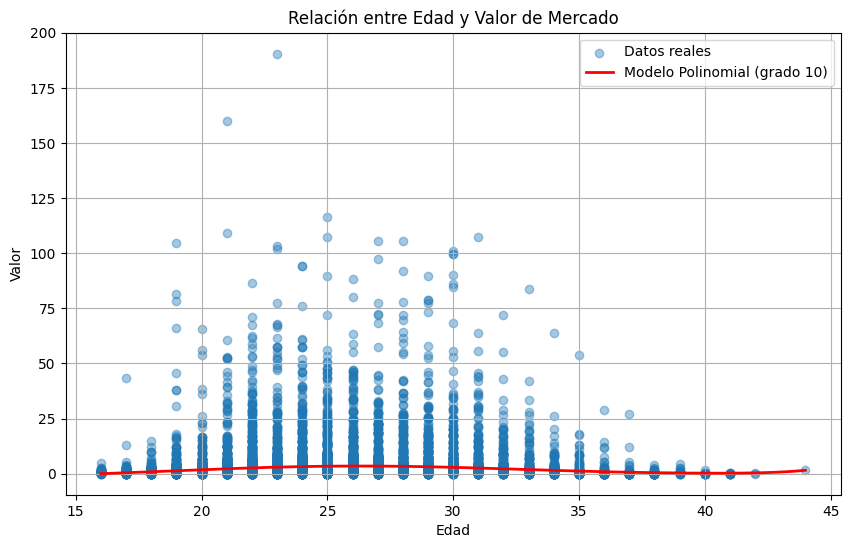

R² del modelo lineal simple con age: 0.001
R² del modelo polinomial (grado 10): 0.017


In [51]:
degree = 10
modelo_polinomial = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
    ('regresion', LinearRegression())
])
# Variable predictora y objetivo
X_poly = df[['age']]
y_poly = df['Value_millions']

# Entrenamiento del modelo
modelo_polinomial.fit(X_poly, y_poly)

# Rango de edades para graficar la curva suavizada
age_range = np.linspace(df['age'].min(), df['age'].max(), 300).reshape(-1, 1)
value_pred = modelo_polinomial.predict(age_range)

# Gráfico
plt.figure(figsize=(10,6))
plt.scatter(df['age'], df['Value_millions'], alpha=0.4, label='Datos reales')
plt.plot(age_range, value_pred, color='red', linewidth=2, label=f'Modelo Polinomial (grado {degree})')
plt.title('Relación entre Edad y Valor de Mercado')
plt.xlabel('Edad')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

# R² del modelo polinomial
r2_poly = r2_score(y_poly, modelo_polinomial.predict(X_poly))

# R² del modelo lineal simple
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_poly, y_poly)
r2_lineal = r2_score(y_poly, modelo_lineal.predict(X_poly))

print(f"R² del modelo lineal simple con age: {r2_lineal:.3f}")
print(f"R² del modelo polinomial (grado {degree}): {r2_poly:.3f}")

| R²      | Interpretación                                                   |
| ------- | ---------------------------------------------------------------- |
| 1.0     | Modelo perfecto (poco común en la práctica).                     |
| 0.7–0.9 | Muy buen ajuste, explica gran parte de la variación.             |
| 0.5–0.7 | Ajuste razonable, útil en muchos contextos prácticos.            |
| 0.3–0.5 | Ajuste débil, pero puede ser aceptable dependiendo del problema. |
| < 0.3   | Modelo con bajo poder predictivo. Necesita mejoras.              |
| < 0.0   | Modelo peor que una línea horizontal (muy raro, pero posible).   |


### Un R² de 1.0 no siempre es bueno si se logra con un modelo muy complejo, ya que puede ser resultado de overfitting (el modelo memorizó los datos en lugar de aprender una tendencia real)